In [ ]:
!pip install opencv-python-headless

In [ ]:
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow import keras


Success


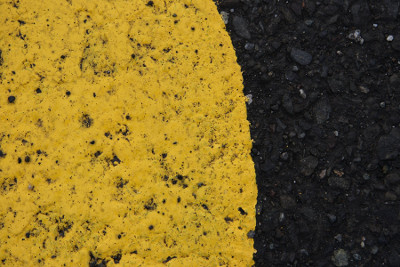

In [ ]:
from google.colab.patches import cv2_imshow

image = cv2.imread("q5_pave.jpg")

if image is None:
    print("Error: Image not found")
else:
    print("Success")
    cv2_imshow(image)

Resized Image


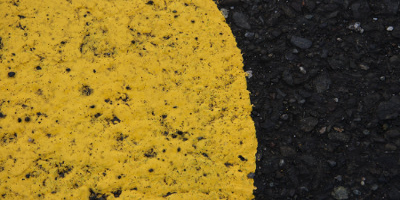

In [ ]:
# Resize image to 300x300 pixels
resized = cv2.resize(image, (400, 200))

print("Resized Image")
cv2_imshow(resized)


Cropped Image


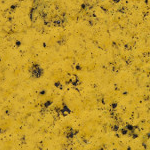

In [ ]:
# Crop the region from (x=50, y=50) to (x=200, y=200)
cropped = image[50:200, 50:200]

print("Cropped Image")
cv2_imshow(cropped)


Rotated Image


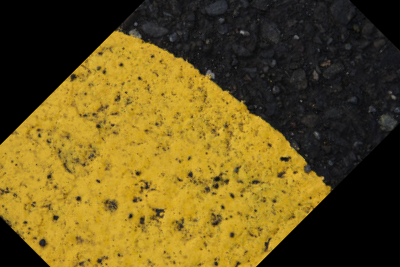

In [ ]:
(h, w) = image.shape[:2]  # Get image height and width
center = (w // 2, h // 2)  # Compute the center of the image

# Rotate image by 45 degrees
M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(image, M, (w, h))

print("Rotated Image")
cv2_imshow(rotated)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


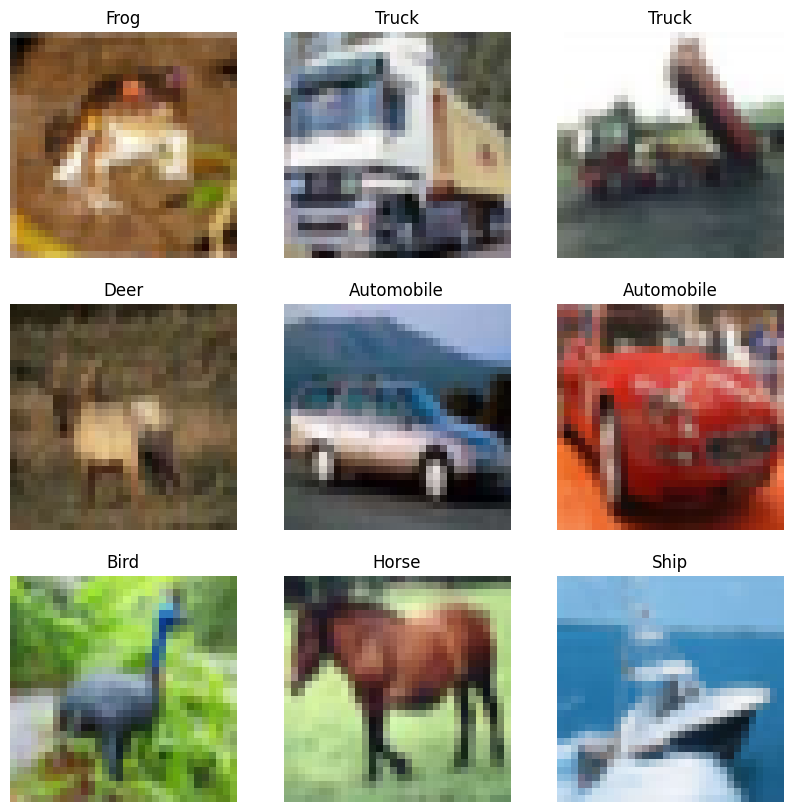

In [ ]:
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Print dataset shape
print("x_train shape:", x_train.shape)  # Training images
print("y_train shape:", y_train.shape)  # Training labels
print("x_test shape:", x_test.shape)    # Test images
print("y_test shape:", y_test.shape)    # Test labels


# Define class labels
class_labels = ["Airplane", "Automobile", "Bird", "Cat", "Deer",
                "Dog", "Frog", "Horse", "Ship", "Truck"]

# Plot first 9 images with labels
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)  # Create a 3x3 grid
    plt.imshow(x_train[i])  # Show image
    plt.title(class_labels[y_train[i][0]])  # Get label
    plt.axis("off")  # Hide axis

plt.show()


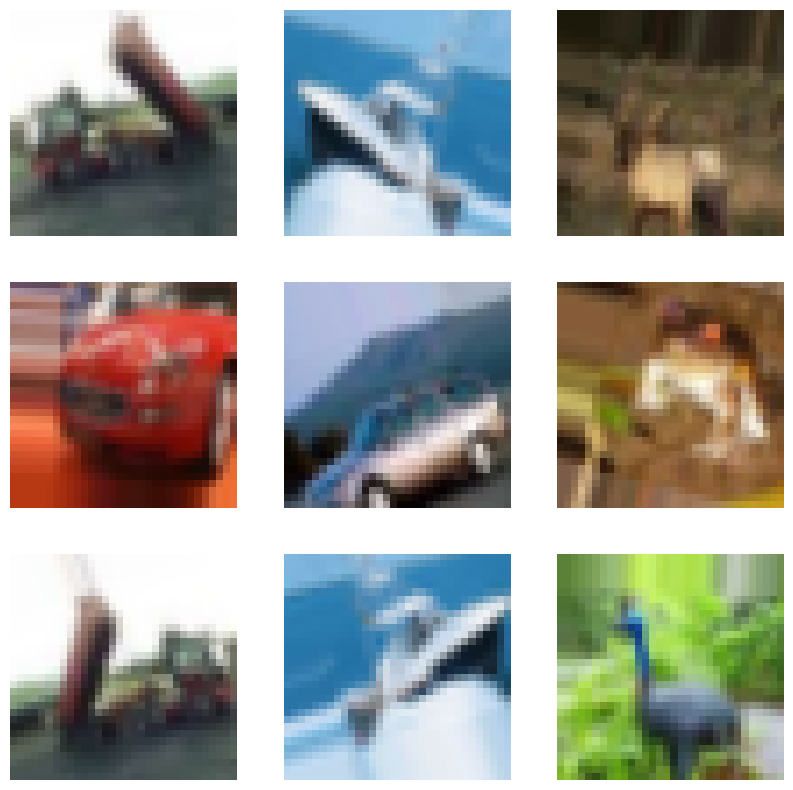

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Define Data Augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=20,       # Rotate up to 20 degrees
    width_shift_range=0.2,   # Shift width by 20%
    height_shift_range=0.2,  # Shift height by 20%
    horizontal_flip=True,    # Randomly flip images horizontally
)

# Fit the generator to the training data (important for computing statistics)
datagen.fit(x_train)

# Generate augmented images
augmented_images = datagen.flow(x_train[:9], batch_size=9)  # Get 9 images

# Plot augmented images
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = next(augmented_images)[0].astype(np.uint8)  # Get next augmented image
    plt.imshow(img)
    plt.axis("off")

plt.show()


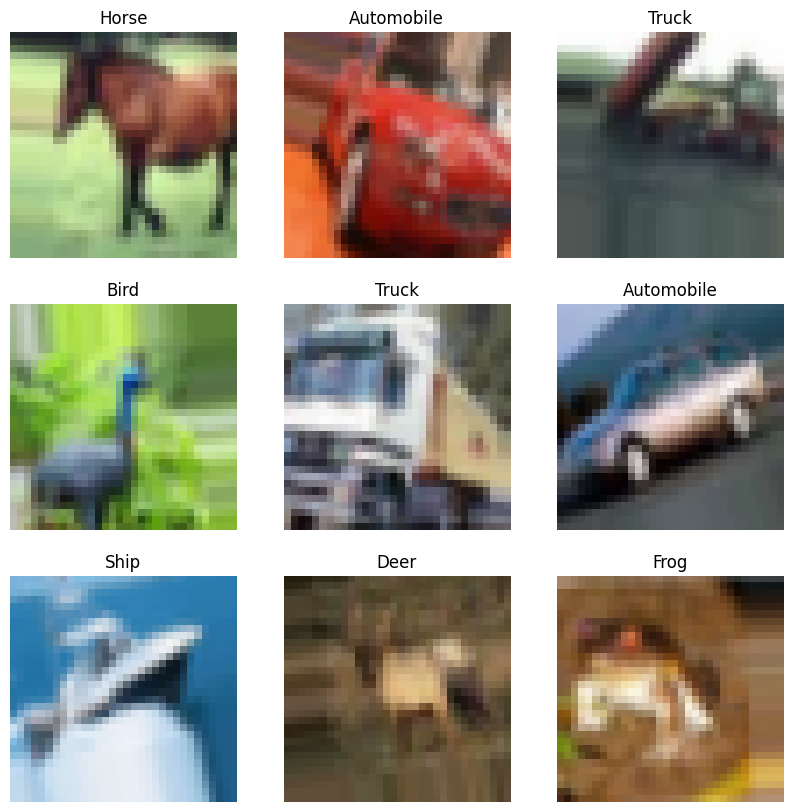

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Class labels (CIFAR-10 classes)
class_labels = ["Airplane", "Automobile", "Bird", "Cat", "Deer",
                "Dog", "Frog", "Horse", "Ship", "Truck"]

# Define Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
)

# Fit the generator
datagen.fit(x_train)

# Create augmented image generator with labels
augmented_images = datagen.flow(x_train[:9], y_train[:9], batch_size=9)

# Plot augmented images with labels
plt.figure(figsize=(10, 10))
batch_images, batch_labels = next(augmented_images)  # Get one batch

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = batch_images[i].astype(np.uint8)  # Convert to uint8
    label = class_labels[batch_labels[i][0]]  # Get class label
    plt.imshow(img)
    plt.title(label)  # Display label
    plt.axis("off")

plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Split only the training set (50,000 images) into 80% train, 20% validation
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Verify dataset shapes
print("Training set:", x_train.shape, y_train.shape)
print("Validation set:", x_val.shape, y_val.shape)
print("Test set:", x_test.shape, y_test.shape)  # Should remain 10,000

# Normalize images to range [0,1]
x_train = x_train.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Verify normalization (should print 0.0 and 1.0)
print("Train min/max:", x_train.min(), x_train.max())
print("Val min/max:", x_val.min(), x_val.max())
print("Test min/max:", x_test.min(), x_test.max())

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_val = to_categorical(y_val, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Verify one-hot encoding (print first 5 labels)
print("Sample one-hot label:", y_train[:5])


Training set: (40000, 32, 32, 3) (40000, 1)
Validation set: (10000, 32, 32, 3) (10000, 1)
Test set: (10000, 32, 32, 3) (10000, 1)
Train min/max: 0.0 1.0
Val min/max: 0.0 1.0
Test min/max: 0.0 1.0
Sample one-hot label: [[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Initialize the CNN model
model = models.Sequential([
    # 1st Convolutional Layer
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2,2)),

    # 2nd Convolutional Layer
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # 3rd Convolutional Layer
    layers.Conv2D(128, (3,3), activation='relu'),

    # Flatten the output before passing to Dense layers
    layers.Flatten(),

    # Fully Connected Layer with Dropout
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output Layer (10 classes with softmax)
    layers.Dense(10, activation='softmax')
])

# Print the model summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train,
                    epochs=20, batch_size=64,
                    validation_data=(x_test, y_test))



Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 103ms/step - accuracy: 0.2759 - loss: 1.9336 - val_accuracy: 0.5157 - val_loss: 1.3310
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 94ms/step - accuracy: 0.4965 - loss: 1.4006 - val_accuracy: 0.5683 - val_loss: 1.2162
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 99ms/step - accuracy: 0.5631 - loss: 1.2266 - val_accuracy: 0.6125 - val_loss: 1.1029
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.6118 - loss: 1.1007 - val_accuracy: 0.6476 - val_loss: 1.0028
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 99ms/step - accuracy: 0.6484 - loss: 1.0217 - val_accuracy: 0.6564 - val_loss: 0.9734
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 94ms/step - accuracy: 0.6720 - loss: 0.9424 - val_accuracy: 0.6713 - val_loss: 0.9361
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 96ms/step - accuracy: 0.6950 - loss: 0.8779 - val_accuracy: 0.6892 - val_loss: 0.9003
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7091 - loss: 0.8214 -

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)

print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


313/313 - 4s - 13ms/step - accuracy: 0.7287 - loss: 0.9495

Test Accuracy: 72.87%
Test Loss: 0.9495


Adjusting Learning Rate.....

In [ ]:
import tensorflow as tf

# Define a function for exponential decay
def lr_scheduler(epoch, lr):
    decay_rate = 0.1
    decay_step = 10
    if epoch % decay_step == 0 and epoch > 0:
        return lr * decay_rate
    return lr

# Callback for learning rate adjustment
lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)


In [ ]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# One-hot encode labels (10 classes)
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Split training data (20% for validation)
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Load ResNet50 pretrained model
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(32, 32, 3))

# Freeze the base model (so pretrained weights remain unchanged)
base_model.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Create a new model on top of ResNet50
model = models.Sequential([
    base_model,                         # Pretrained ResNet50 model
    layers.GlobalAveragePooling2D(),    # Convert features to a single vector
    layers.Dense(256, activation='relu'),  # Fully connected layer
    layers.Dropout(0.5),                # Dropout to prevent overfitting
    layers.Dense(10, activation='softmax') # Output layer for 10 classes
])


In [ ]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # Start with a higher LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 1, 1, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Train the model with Learning Rate Scheduler
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1,
    batch_size=64,
    callbacks=[lr_callback],  # Use LR scheduler
    verbose=1
)


625/625 ━━━━━━━━━━━━━━━━━━━━ 200s 320ms/step - accuracy: 0.1451 - loss: 2.2246 - val_accuracy: 0.2039 - val_loss: 2.1366 - learning_rate: 0.0010


In [ ]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")


313/313 - 42s - 133ms/step - accuracy: 0.2113 - loss: 2.1342

Final Test Accuracy: 21.13%


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class labels from y_train (convert one-hot encoding back to class indices)
y_train_classes = np.argmax(y_train, axis=1)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_classes), y=y_train_classes)

# Convert class weights to dictionary format
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("Computed Class Weights:", class_weight_dict)


Computed Class Weights: {0: np.float64(0.9932952570151478), 1: np.float64(0.9947774185525988), 2: np.float64(1.0075566750629723), 3: np.float64(1.0057832537088258), 4: np.float64(0.9835259404966806), 5: np.float64(1.0037641154328734), 6: np.float64(0.999000999000999), 7: np.float64(0.9985022466300549), 8: np.float64(1.0042681395932713), 9: np.float64(1.0101010101010102)}


Break...

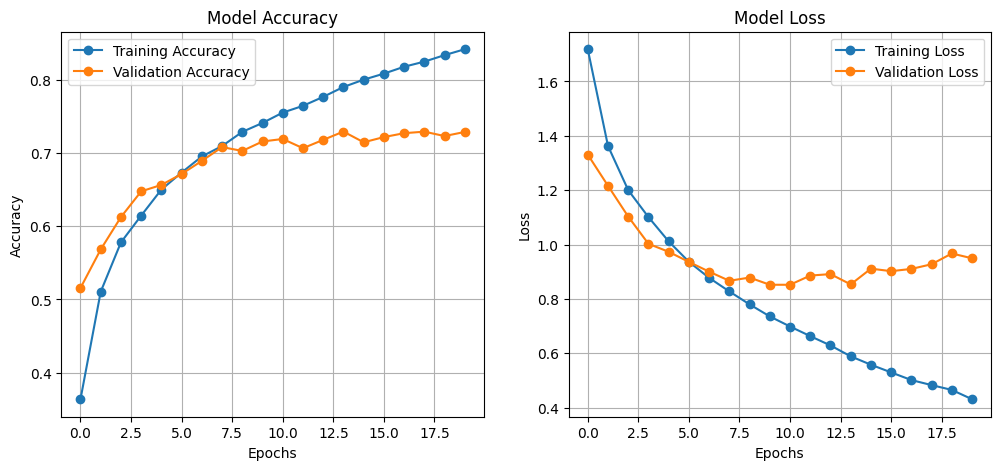

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()


In [ ]:
!pip install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.7 MB/s eta 0:00:00


In [ ]:
# Install Keras-Tuner
!pip install keras-tuner

# Import required libraries
import tensorflow as tf
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 1.6 MB/s eta 0:00:00


In [ ]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to the range [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Convert labels to one-hot encoding (for 10 classes)
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Split dataset: 20% of training data for validation
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

print(f"Training Set: {x_train.shape}, {y_train.shape}")
print(f"Validation Set: {x_val.shape}, {y_val.shape}")
print(f"Test Set: {x_test.shape}, {y_test.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training Set: (40000, 32, 32, 3), (40000, 10)
Validation Set: (10000, 32, 32, 3), (10000, 10)
Test Set: (10000, 32, 32, 3), (10000, 10)


In [ ]:
from keras_tuner import HyperModel

# Define a HyperModel class for tuning
class CNNHyperModel(HyperModel):
    def build(self, hp):
        model = keras.Sequential()

        # First Convolutional Layer
        model.add(layers.Conv2D(
            filters=hp.Int('conv1_filters', min_value=32, max_value=128, step=32),
            kernel_size=hp.Choice('conv1_kernel', values=[3, 5]),
            activation='relu',
            input_shape=(32, 32, 3)
        ))
        model.add(layers.MaxPooling2D((2,2)))

        # Second Convolutional Layer
        model.add(layers.Conv2D(
            filters=hp.Int('conv2_filters', min_value=64, max_value=256, step=64),
            kernel_size=hp.Choice('conv2_kernel', values=[3, 5]),
            activation='relu'
        ))
        model.add(layers.MaxPooling2D((2,2)))

        # Flatten layer
        model.add(layers.Flatten())

        # Fully Connected Layer
        model.add(layers.Dense(
            units=hp.Int('dense_units', min_value=64, max_value=256, step=64),
            activation='relu'
        ))

        # Dropout Layer (to prevent overfitting)
        model.add(layers.Dropout(hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)))

        # Output Layer (10 classes for CIFAR-10)
        model.add(layers.Dense(10, activation='softmax'))

        # Compile model
        model.compile(
            optimizer=keras.optimizers.Adam(
                hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')
            ),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        return model


In [ ]:
from keras_tuner.tuners import RandomSearch

# Initialize Random Search Tuner
tuner = RandomSearch(
    CNNHyperModel(),
    objective='val_accuracy',  # Optimize for validation accuracy
    max_trials=10,             # Try 10 different hyperparameter combinations
    executions_per_trial=1,    # Run each trial once
    directory='keras_tuner_dir',
    project_name='cifar10_tuning'
)


In [9]:
# Perform hyperparameter search
tuner.search(x_train, y_train,
             validation_data=(x_val, y_val),
             epochs=10,
             batch_size=64,
             verbose=1)


Trial 10 Complete [00h 31m 30s]
val_accuracy: 0.6431000232696533

Best val_accuracy So Far: 0.7093999981880188
Total elapsed time: 06h 05m 55s
